# Bank Churn Deep Learning Pipeline
This notebook builds a complete neural network pipeline step by step.

Pipeline flow:
1. Import libraries
2. Load and inspect data
3. Clean and encode features
4. Split train/validation/test
5. Scale numeric features correctly
6. Build and train neural network
7. Evaluate with default threshold
8. Tune threshold on validation and report final test metrics

## Step 1: Import Libraries and Set Random Seed
We import all required libraries and fix random seeds for reproducible results.

In [153]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

## Step 2: Load Dataset
Read the CSV file and view the first few rows.

In [154]:
df = pd.read_csv('data/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Quick Data Check
Check shape, missing values, and target class balance.

In [155]:
print('Shape:', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nClass distribution (Exited):')
print(df['Exited'].value_counts())

Shape: (10000, 14)

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Class distribution (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64


## Step 4: Drop Unused Columns
Remove identifier columns that do not help prediction.

In [156]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 5: Encode Categorical Features
Use one-hot encoding for Gender and Geography.

In [157]:
df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True, dtype=int)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1


## Step 6: Create Features and Target
Split data into input features X and target y.

In [158]:
X = df.drop('Exited', axis=1).copy()
y = df['Exited'].copy()
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (10000, 11)
y shape: (10000,)


## Step 7: Train, Validation, and Test Split
We keep test data unseen and use validation data for tuning.

In [159]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)
print('Test shape:', X_test.shape)

Train shape: (6400, 11)
Validation shape: (1600, 11)
Test shape: (2000, 11)


## Step 8: Scale Numeric Features
Fit scaler only on training data, then transform validation and test data.

In [160]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Male,Geography_Germany,Geography_Spain
3006,0.794,0.364865,0.1,0.482236,0.000000,1,0,0.946824,0,0,0
5735,0.470,0.351351,0.4,0.000000,0.333333,0,1,0.508440,0,0,1
5652,0.682,0.148649,0.9,0.000000,0.333333,0,0,0.998216,0,0,0
26,0.812,0.243243,0.2,0.573921,0.000000,1,1,0.850174,1,1,0
3596,0.586,0.243243,0.0,0.621508,0.000000,0,0,0.278864,1,0,0


## Step 9: Build Neural Network
Define a simple dense network with dropout regularization.

In [161]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 10: Train Model
Train with early stopping to avoid overfitting and keep the best validation model.

In [162]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80


2026-03-19 22:37:21.790122: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6450 - auc: 0.5355 - loss: 0.6157 - val_accuracy: 0.7962 - val_auc: 0.6656 - val_loss: 0.4793
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7920 - auc: 0.6512 - loss: 0.4886 - val_accuracy: 0.7962 - val_auc: 0.6935 - val_loss: 0.4675
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7935 - auc: 0.6912 - loss: 0.4728 - val_accuracy: 0.7962 - val_auc: 0.7104 - val_loss: 0.4593
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7948 - auc: 0.7140 - loss: 0.4632 - val_accuracy: 0.7962 - val_auc: 0.7208 - val_loss: 0.4545
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7989 - auc: 0.7199 - loss: 0.4619 - val_accuracy: 0.8000 - val_auc: 0.7365 - val_loss: 0.4454
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8027 - auc: 0.7345 - loss: 0.4527 - val_accuracy: 0.8069 - val_auc: 0.7442 - val_loss: 0.4413
Epoch 7/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17

## Step 11: Evaluate with Default Threshold (0.5)
First, check performance using the default classification threshold.

In [163]:
test_prob_default = model.predict(X_test).ravel()
y_pred_default = (test_prob_default >= 0.5).astype(int)

print('Default Threshold = 0.5')
print('Accuracy:', round(accuracy_score(y_test, y_pred_default), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, test_prob_default), 4))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_default))
print('Classification Report:\n', classification_report(y_test, y_pred_default, digits=4))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2026-03-19 22:40:04.904807: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Default Threshold = 0.5
Accuracy: 0.863
ROC-AUC: 0.8579
Confusion Matrix:
 [[1559   34]
 [ 240  167]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8666    0.9787    0.9192      1593
           1     0.8308    0.4103    0.5493       407

    accuracy                         0.8630      2000
   macro avg     0.8487    0.6945    0.7343      2000
weighted avg     0.8593    0.8630    0.8440      2000



## Step 12: Tune Threshold on Validation Set
Find the threshold that maximizes F1 score on validation data.

In [164]:
val_prob = model.predict(X_val).ravel()
best_thr, best_f1 = 0.5, -1.0

for t in np.arange(0.20, 0.81, 0.01):
    val_pred = (val_prob >= t).astype(int)
    score = f1_score(y_val, val_pred)
    if score > best_f1:
        best_f1 = score
        best_thr = t

print('Best threshold from validation:', round(best_thr, 2))
print('Best validation F1:', round(best_f1, 4))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best threshold from validation: 0.31
Best validation F1: 0.6285


## Step 13: Final Test Evaluation with Tuned Threshold
Use the selected threshold for final test predictions and visualize confusion matrix.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold used: 0.31
Accuracy: 0.8455
ROC-AUC: 0.8579
Confusion Matrix:
 [[1444  149]
 [ 160  247]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9002    0.9065    0.9033      1593
           1     0.6237    0.6069    0.6152       407

    accuracy                         0.8455      2000
   macro avg     0.7620    0.7567    0.7593      2000
weighted avg     0.8440    0.8455    0.8447      2000



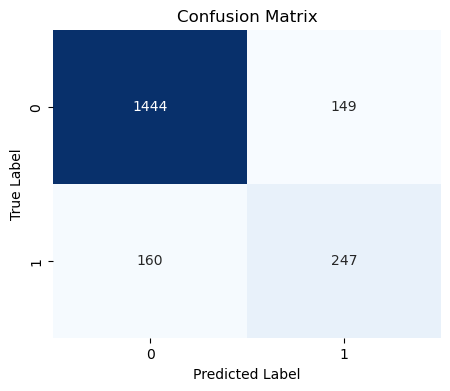

In [165]:
test_prob = model.predict(X_test).ravel()
y_pred = (test_prob >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred)

print('Threshold used:', round(best_thr, 2))
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, test_prob), 4))
print('Confusion Matrix:\n', cm)
print('Classification Report:\n', classification_report(y_test, y_pred, digits=4))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()